In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/raw/Steel_industry_data.csv")
df = pd.read_csv(DATA_PATH)
df.shape

(35040, 11)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [4]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
df = df.set_index("date").sort_index()
df.index.min(), df.index.max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2018-12-31 23:45:00'))

In [5]:
n_duplicates = df.index.duplicated().sum()

expected = pd.date_range(df.index.min(), df.index.max(), freq="15min")
missing = expected.difference(df.index)

print(f"Doublons : {n_duplicates}")
print(f"Pas de temps attendus : {len(expected)}, présents : {len(df)}, manquants : {len(missing)}")

Doublons : 0
Pas de temps attendus : 35040, présents : 35040, manquants : 0


In [6]:
df.isna().sum()
df.head()
difference = df.index.day_name() != df['Day_of_week']
difference.sum()

np.int64(0)

In [7]:
df.columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2(tCO2),35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
NSM,35040.0,42750.000000,24940.534317,0.0,21375.00,42750.00,64125.0000,85500.00


<Axes: >

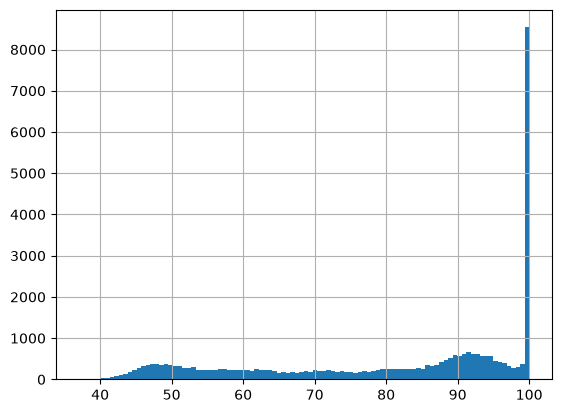

In [8]:
import numpy as np

P = df["Usage_kWh"]
Q = df["Lagging_Current_Reactive.Power_kVarh"]          # la colonne d'énergie réactive "lagging"

pf_calc = 100 * P / np.sqrt(P**2+Q**2)

ecart = (pf_calc - df["Lagging_Current_Power_Factor"]).abs() # la colonne de facteur de puissance "lagging"
ecart /= 100
ecart.describe()
pf_calc.hist(bins = 100)

628.72 2018-11-22 09:45:00 Thursday


count    35040.000000
mean       109.547570
std        133.777519
min          0.000000
25%         12.800000
50%         18.280000
75%        204.950000
max        628.720000
Name: power_kW, dtype: float64

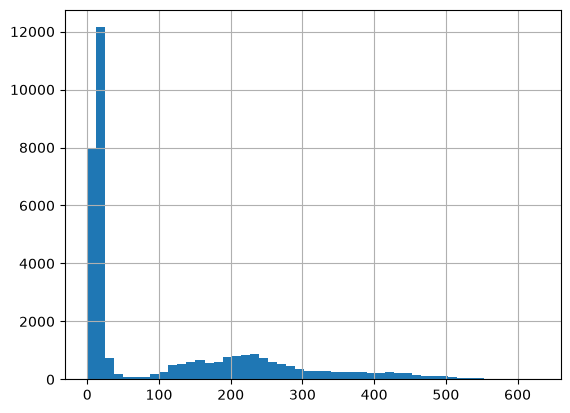

In [9]:
df["power_kW"] = df["Usage_kWh"] * 60/15

pointe = df["power_kW"].max()          # la valeur maximale
moment = df["power_kW"].idxmax() # l'horodatage du maximum (indice : idx...)
day = moment.day_name()
print(pointe, moment, day)
df["power_kW"].hist(bins = 50)
df["power_kW"].describe()

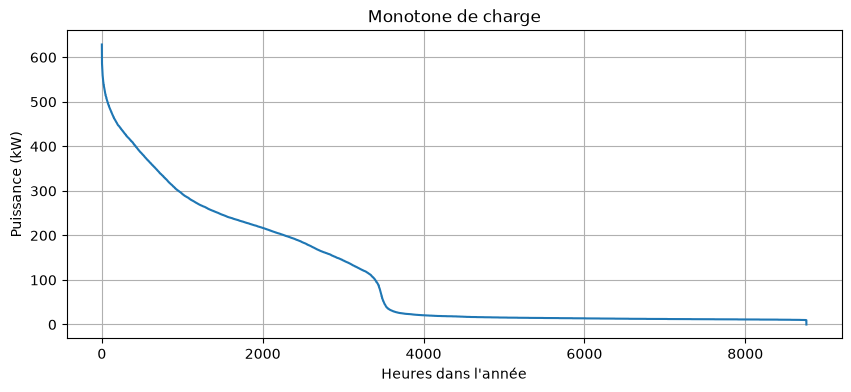

In [10]:
monotone = df["power_kW"].sort_values(ascending=False).reset_index(drop=True)
heures = monotone.index / 4          # 4 intervalles par heure
plt.figure(figsize=(10, 4))
plt.plot(heures, monotone)
plt.xlabel("Heures dans l'année")
plt.ylabel("Puissance (kW)")
plt.title("Monotone de charge")
plt.grid(True)

In [15]:
daily = pd.DataFrame({
    "energy_kWh": df["Usage_kWh"].resample("D").sum(),
    "peak_kW":    df["power_kW"].resample("D").max(),
    "co2_t":      df["CO2(tCO2)"].resample("D").sum(),
})

monthly = daily.resample("MS").agg({
    "energy_kWh": "sum",
    "peak_kW": "max",
    "co2_t": "sum",
})
monthly["Form_factor"] = monthly["peak_kW"]/(df["power_kW"].resample("D").mean())

In [20]:
monthly

,energy_kWh,peak_kW,co2_t,Form_factor
date,,,,
2018-01-01,126238.29,612.56,53.99,41.782072
2018-02-01,91497.34,582.04,39.24,2.284503
2018-03-01,80230.41,605.24,33.64,8.674996
2018-04-01,78769.80,556.12,33.35,46.052308
2018-05-01,79059.28,560.16,33.51,45.015369
2018-06-01,65404.64,535.40,27.10,6.267853
2018-07-01,81674.41,486.72,35.02,40.583956
2018-08-01,68559.43,534.80,28.44,47.890750
2018-09-01,57883.07,510.48,23.92,8.821850


In [ ]:
mo